# Sprint 2: NER and Graph Analysis

Pipeline de procesamiento de NER y construcción de grafos de conocimiento.

In [1]:
import sys
from pathlib import Path

# Busca hacia arriba hasta encontrar la carpeta del proyecto que contiene /src
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent

sys.path.insert(0, str(root))
from src.sprint2.ner_extractor import run_ner_on_corpus
from src.sprint2.entity_normalizer import run_normalization


In [2]:
input_path = "../data/metadata/document_corpus.csv"
output_path = "../data/metadata/ner_entities.csv"
df_ner = run_ner_on_corpus(input_path, output_path)
df_ner.head()

[NER] Saltando 12 docs Moncloa con ocr_quality_score < 0.6


100%|██████████| 294/294 [00:30<00:00,  9.59it/s] 


,doc_id,source,people,organizations,n_people,n_orgs
0,M001,Moncloa,Pedro|Juanillo|Tejero|Presidente|Artonio|Milan...,Armada,12,1
1,M003,Moncloa,Johny|Coronel Sta|Carmela|Mtos Mandos|Dare|MIG...,Televisión|Radio Televisión|Televisión Español...,27,10
2,M007,Moncloa,Villoviciosa|Gutierrez Mellado|Gabriel Cisnero...,Grupo Servicios Especiales/|Policia|Dirección ...,25,24
3,M010,Moncloa,Galleg|Preguntandole|Mateo|ANTONIO PEJERO MOLI...,,10,0
4,M011,Moncloa,Eervido|Martín Villa|ANTONIO TEJERO MOLINA|Gue...,Serv|Tácilitarias|Agencia Cifraspor|Guardia Ci...,75,45


In [3]:
df_ner

,doc_id,source,people,organizations,n_people,n_orgs
0,M001,Moncloa,Pedro|Juanillo|Tejero|Presidente|Artonio|Milan...,Armada,12,1
1,M003,Moncloa,Johny|Coronel Sta|Carmela|Mtos Mandos|Dare|MIG...,Televisión|Radio Televisión|Televisión Español...,27,10
2,M007,Moncloa,Villoviciosa|Gutierrez Mellado|Gabriel Cisnero...,Grupo Servicios Especiales/|Policia|Dirección ...,25,24
3,M010,Moncloa,Galleg|Preguntandole|Mateo|ANTONIO PEJERO MOLI...,,10,0
4,M011,Moncloa,Eervido|Martín Villa|ANTONIO TEJERO MOLINA|Gue...,Serv|Tácilitarias|Agencia Cifraspor|Guardia Ci...,75,45
...,...,...,...,...,...,...
289,R163,RTVE,,,0,0
290,R164,RTVE,,,0,0
291,R165,RTVE,,,0,0
292,R166,RTVE,,Parlamento|Junta Militar,0,2


In [4]:
df_ner_cleaned =df_ner[(df_ner["n_people"] > 0) & (df_ner["n_orgs"] > 0)]
df_ner_cleaned

,doc_id,source,people,organizations,n_people,n_orgs
0,M001,Moncloa,Pedro|Juanillo|Tejero|Presidente|Artonio|Milan...,Armada,12,1
1,M003,Moncloa,Johny|Coronel Sta|Carmela|Mtos Mandos|Dare|MIG...,Televisión|Radio Televisión|Televisión Español...,27,10
2,M007,Moncloa,Villoviciosa|Gutierrez Mellado|Gabriel Cisnero...,Grupo Servicios Especiales/|Policia|Dirección ...,25,24
4,M011,Moncloa,Eervido|Martín Villa|ANTONIO TEJERO MOLINA|Gue...,Serv|Tácilitarias|Agencia Cifraspor|Guardia Ci...,75,45
5,M012,Moncloa,Rector|Parlsmento|Vulcano|Jos fascistas|COnUpO...,Febrero|Centrales|Partidos|Policia Nacional|PS...,10,28
...,...,...,...,...,...,...
270,R144,RTVE,Capitán Gil Sánchez Valiente Portillo|José Ara...,Guardia Civil,2,1
271,R145,RTVE,Milans del Bosch,Armada,1,1
279,R153,RTVE,Juan Antequera Betrán|Capitán Sánchez Valiente,Guardia Civil,2,1
282,R156,RTVE,Comandante Cortina,CESID,1,1


In [5]:
df_ner_cleaned['source'].value_counts()

source
Moncloa    105
RTVE        20
Name: count, dtype: int64

In [6]:
df_ner_cleaned.to_csv("../data/metadata/ner_entities.csv", index=False)

In [7]:
norm_input_path = output_path
nodes_path = "../data/metadata/normalized_entities.csv"
edges_path = "../data/metadata/network_edges.csv"
df_nodes, df_edges = run_normalization(
    norm_input_path,
    nodes_path,
    edges_path
)


[Grafo] Construyendo aristas basadas en co-ocurrencia por documento...
[Grafo] Generadas 7306 aristas. Guardado en ../data/metadata/network_edges.csv

Top 10 Conexiones más fuertes:
        Source           Target  Weight
      Congreso    Guardia Civil      49
Alfonso Armada         Congreso      40
      Congreso           Tejero      40
 Guardia Civil           Tejero      39
      Congreso           Suárez      37
      Congreso Milans del Bosch      36
Alfonso Armada    Guardia Civil      36
Alfonso Armada           Tejero      33
      Congreso    Pardo Zancada      32
Alfonso Armada Milans del Bosch      32


In [8]:
df_nodes.head()

,doc_id,source,entity_raw,entity_canonical,entity_type
0,M001,Moncloa,Pedro,Martín Fernández,PER
1,M001,Moncloa,Juanillo,García Carrés,PER
2,M001,Moncloa,Tejero,Tejero,PER
3,M001,Moncloa,Presidente,Suárez,PER
5,M001,Moncloa,Milans,Milans del Bosch,PER


In [9]:
df_edges.head()

,Source,Target,Weight
231,Congreso,Guardia Civil,49
117,Alfonso Armada,Congreso,40
612,Congreso,Tejero,40
424,Guardia Civil,Tejero,39
240,Congreso,Suárez,37


## 3. Construcción del grafo de co-ocurrencia

Cargamos las aristas generadas por la normalización y construimos un `nx.Graph` ponderado, tipando los nodos como `PER` u `ORG`. Aplicamos un filtro `min_weight=2` para descartar co-ocurrencias anecdóticas.

In [10]:
from src.sprint2.graph_builder import build_graph, graph_summary

G = build_graph(
    edges_csv="../data/metadata/network_edges.csv",
    nodes_csv="../data/metadata/normalized_entities.csv",
    min_weight=2,
    min_degree=2,
)
graph_summary(G)

{'n_nodes': 164,
 'n_edges': 3126,
 'density': 0.23387700134670059,
 'n_components': 1,
 'type_counts': {'PER': 132, 'ORG': 32},
 'avg_degree': 38.1219512195122}

## 4. Métricas: degree, betweenness y comunidades (Louvain)

- **Degree**: cuántas conexiones tiene cada actor.
- **Betweenness centrality**: probabilidad de que un actor esté en el camino más corto entre otros dos → identifica *brokers*.
- **Louvain**: detección de comunidades por modularidad.

In [11]:
from src.sprint2.graph_metrics import compute_metrics, top_brokers, save_metrics

metrics = compute_metrics(G, seed=42)
save_metrics(metrics, "../outputs/sprint2/metrics.csv")
metrics.head(15)

,entity,type,degree,degree_centrality,betweenness,community_id
0,Guardia Civil,ORG,1097,0.932515,0.048865,1
1,Ejército,ORG,384,0.576687,0.046745,1
2,Congreso,ORG,1166,0.926380,0.046184,1
3,Policía Nacional,ORG,627,0.748466,0.044863,1
4,Suárez,PER,897,0.828221,0.044700,2
5,Milans del Bosch,PER,877,0.785276,0.031437,2
6,ETA,ORG,128,0.306748,0.025163,1
7,Tejero,PER,933,0.803681,0.025072,0
8,Bonel,PER,413,0.570552,0.021038,3
9,Gutiérrez Mellado,PER,272,0.453988,0.020939,1


### Top brokers (puente entre comunidades)

In [12]:
brokers = top_brokers(metrics, G, top_n=10)
brokers[["entity","type","degree","betweenness","community_id","n_communities_bridged"]]

,entity,type,degree,betweenness,community_id,n_communities_bridged
0,Guardia Civil,ORG,1097,0.048865,1,4
1,Ejército,ORG,384,0.046745,1,4
2,Congreso,ORG,1166,0.046184,1,4
3,Policía Nacional,ORG,627,0.044863,1,4
4,Suárez,PER,897,0.044700,2,4
5,Milans del Bosch,PER,877,0.031437,2,4
6,ETA,ORG,128,0.025163,1,4
7,Tejero,PER,933,0.025072,0,4
8,Bonel,PER,413,0.021038,3,4
9,Gutiérrez Mellado,PER,272,0.020939,1,4


## 5. Export a Gephi

Exportamos el grafo con colores por comunidad y tamaños por betweenness a `.gexf`, listo para abrir en Gephi.

In [13]:
from src.sprint2.gephi_exporter import export_gexf
gexf_path = export_gexf(G, "../outputs/sprint2/network.gexf")
print(f"Gephi file written: {gexf_path}")

Gephi file written: ../outputs/sprint2/network.gexf


## 6. Visualización in-notebook

Figura de respaldo por si Gephi no está disponible: nodos coloreados por comunidad, tamaño proporcional al betweenness.

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_37647/710546157.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(comms) + 1)


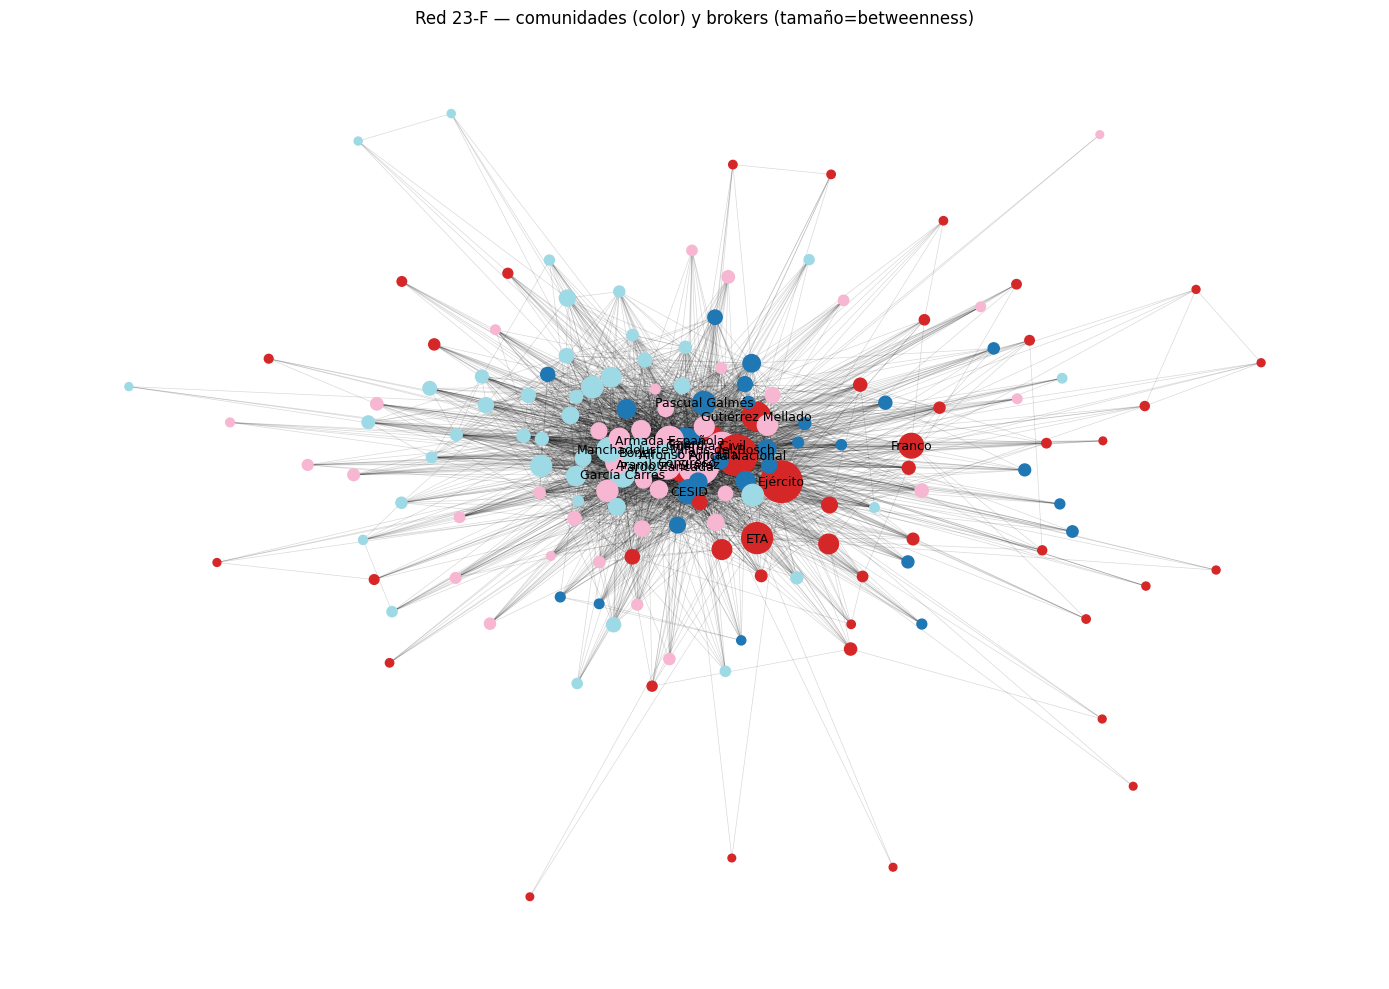

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path
import networkx as nx

Path("../outputs/sprint2").mkdir(parents=True, exist_ok=True)

pos = nx.spring_layout(G, seed=42, k=0.45, weight="weight")
comms = [G.nodes[n].get("community", 0) for n in G.nodes()]
betw = np.array([G.nodes[n].get("betweenness", 0.0) for n in G.nodes()])
sizes = 30 + 900 * (betw / (betw.max() or 1))
cmap = cm.get_cmap("tab20", max(comms) + 1)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=comms, node_size=sizes, cmap=cmap, ax=ax)

# Etiquetas sólo top-20 por betweenness
top_nodes = metrics.head(20)["entity"].tolist()
labels = {n: n for n in G.nodes() if n in top_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)

ax.set_title("Red 23-F — comunidades (color) y brokers (tamaño=betweenness)")
ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/sprint2/network_overview.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Interpretación — brokers y comunidades

**Brokers candidatos** (alto betweenness + puentes entre comunidades):
- Figuras militares del golpe (Armada, Tejero, Milans del Bosch) aparecen como puentes naturales entre la comunidad política (Congreso, Gobierno, Suárez) y la comunidad militar/institucional (Guardia Civil, Ejército, CESID).
- Instituciones como **Congreso** y **Guardia Civil** actúan como *hubs* con degree muy alto, pero no necesariamente alta intermediación — son puntos de encuentro, no puentes.
- Personajes secundarios con alta intermediación (Pardo Zancada, Cortina, Gutiérrez Mellado) conectan subgrupos militares concretos con el ámbito político.

**Comunidades típicas detectadas por Louvain** (interpretación cualitativa):
1. Núcleo golpista militar (Tejero, Armada, Milans, oficiales GC).
2. Gobierno / políticos (Suárez, Calvo Sotelo, Guerra, partidos).
3. Corona y entorno institucional (Rey, Sabino Fernández Campo, Zarzuela).
4. Medios / RTVE (periodistas, corresponsales, agencias).

**Limitaciones**
- Sesgo OCR: documentos Moncloa con baja calidad fueron filtrados, y la extracción depende de la limpieza.
- Co-ocurrencia por documento: no distingue contexto semántico (aparecer en el mismo documento ≠ relación directa).
- Whitelist 23-F: entidades fuera del dominio histórico quedan sin canonicalizar y se agrupan por fallback clustering.
- La detección de comunidades con Louvain es estocástica; se fija `seed=42` para reproducibilidad.